# NYC Airbnb 2024 — analisis

**Este notebook es independiente de `note.ipynb`.** El original se conserva
tal cual llego, con su `drive.mount()` y su ruta de Colab. No hay que correr
uno para que funcione el otro, ni comparten estado.

Aqui la limpieza y el modelado **no** viven en celdas: estan en `src/` y
tienen tests. Este notebook solo explora y grafica. Si una celda necesitara
transformar datos para el modelo, esa transformacion pertenece a `src/`,
porque si no acabas con dos versiones de la misma logica y una se queda atras.


In [1]:
import sys
from pathlib import Path

# el notebook vive en la raiz del repo, junto a datasets.csv
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.cleaning import clean
from src.config import RAW_FILE
from src.features import build_features

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

## 1. Carga

Una linea. Toda la limpieza esta en `src/cleaning.py`.

In [2]:
df = build_features(clean(RAW_FILE))
df = df[df["is_price_outlier"] == 0]
print(df.shape)
df[["price", "rating", "bedrooms", "baths", "license_status"]].head()

ids corruptos por Excel: 8050 (38.8%)


sin datos de 'subway', se omiten esas features


sin datos de 'poi', se omiten esas features


(20583, 43)


,price,rating,bedrooms,baths,license_status
0,55.0,5.0,1,<NA>,none
1,144.0,4.67,2,1.0,none
2,187.0,4.17,1,1.0,exempt
3,120.0,4.64,1,1.0,none
4,85.0,4.91,0,1.0,none


## 2. Lo que la limpieza rescata

`rating`, `baths` y `bedrooms` venian como texto con centinelas mezclados
(`'No rating'`, `'New '` con espacio al final, `'Not specified'`, `'Studio'`).
Sin castear, esas tres columnas desaparecen en silencio de cualquier
`.describe()` o `.corr()`.


In [3]:
df[["rating", "bedrooms", "baths", "beds"]].describe().round(2)

,rating,bedrooms,baths,beds
count,16921.0,20583.0,20570.0,20583.00
mean,4.73,1.31,1.18,1.73
std,0.29,0.88,0.48,1.21
min,1.75,0.0,0.0,1.00
25%,4.64,1.0,1.0,1.00
50%,4.81,1.0,1.0,1.00
75%,4.93,2.0,1.0,2.00
max,5.0,15.0,15.5,42.00


In [4]:
# 38.8% de los id venian destruidos por Excel ('1.02E+18')
n = int(df["id_is_corrupt"].sum())
print(f"ids corruptos: {n:,} ({df['id_is_corrupt'].mean():.1%})")

# no son una muestra aleatoria: difieren sistematicamente del resto
df.groupby("id_is_corrupt")[["price", "uses_30night_loophole", "minimum_nights"]].mean().round(3)

ids corruptos: 7,983 (38.8%)


,price,uses_30night_loophole,minimum_nights
id_is_corrupt,,,
0,165.963,0.893,30.170
1,178.636,0.786,26.073


## 3. Distribucion de precio

El corte se hace por IQR sobre `log(price)`, no con el $1,500 arbitrario.


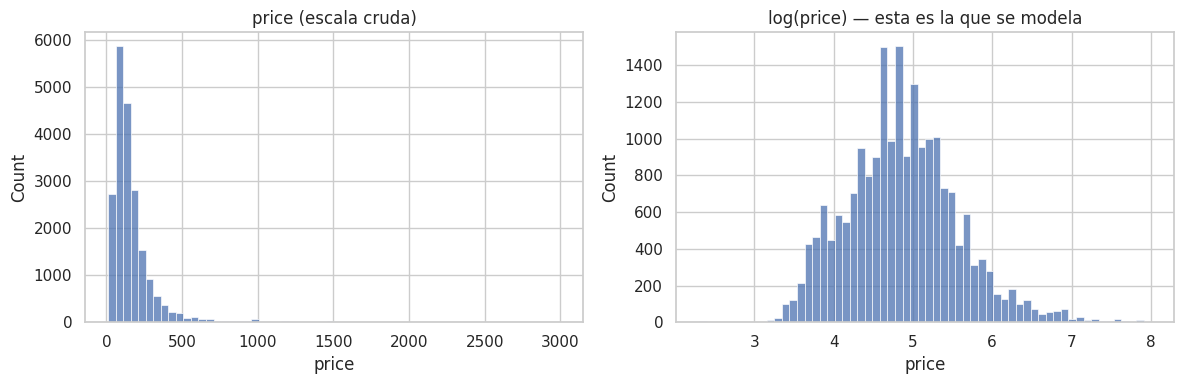

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["price"], bins=60, ax=axes[0])
axes[0].set_title("price (escala cruda)")
sns.histplot(np.log(df["price"]), bins=60, ax=axes[1])
axes[1].set_title("log(price) — esta es la que se modela")
plt.tight_layout()

## 4. Local Law 18 — el hallazgo principal

La ley entro en vigor en septiembre de 2023 y solo regula estancias
**menores a 30 noches**. Este snapshot es de enero de 2024.


In [6]:
tab = pd.crosstab(df["license_status"], df["uses_30night_loophole"])
tab.columns = ["< 30 noches", ">= 30 noches"]
print(tab.to_string(), "\n")
print("porcentaje por fila:")
print((tab.div(tab.sum(axis=1), axis=0) * 100).round(1).to_string())

                < 30 noches  >= 30 noches
license_status                           
registered             1003            45
exempt                 2049            60
none                      7         17419 

porcentaje por fila:
                < 30 noches  >= 30 noches
license_status                           
registered             95.7           4.3
exempt                 97.2           2.8
none                    0.0         100.0


In [7]:
(df.groupby("license_status", observed=True)
   .agg(listings=("price", "size"),
        pct_hueco=("uses_30night_loophole", lambda s: round(100 * s.mean(), 1)),
        precio_mediano=("price", "median"),
        reviews_12m_med=("number_of_reviews_ltm", "median")))

,listings,pct_hueco,precio_mediano,reviews_12m_med
license_status,,,,
registered,1048,4.3,135.0,26.0
exempt,2109,2.8,181.0,6.0
none,17426,100.0,120.0,3.0


De los listings sin licencia, practicamente el 100% exige 30 noches o mas:
quedan siete excepciones en todo el dataset. Los registrados reciben alrededor
de 8 veces mas reservas al año.

**Nota tecnica:** `license_status` y `uses_30night_loophole` son casi la misma
variable. Para el modelo son colineales, conviene usar solo una.


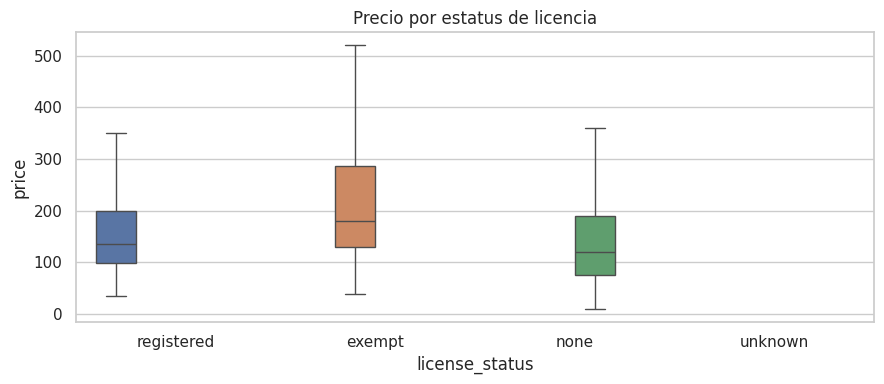

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x="license_status", y="price", hue="license_status",
            legend=False, showfliers=False, ax=ax)
ax.set_title("Precio por estatus de licencia")
plt.tight_layout()

## 5. Reinterpretando la bimodalidad de `availability_365`

El EDA original lee los dos picos (0 y 365) como "estrategia del host".
Vale la pena ver si se explica mejor por el estatus regulatorio.


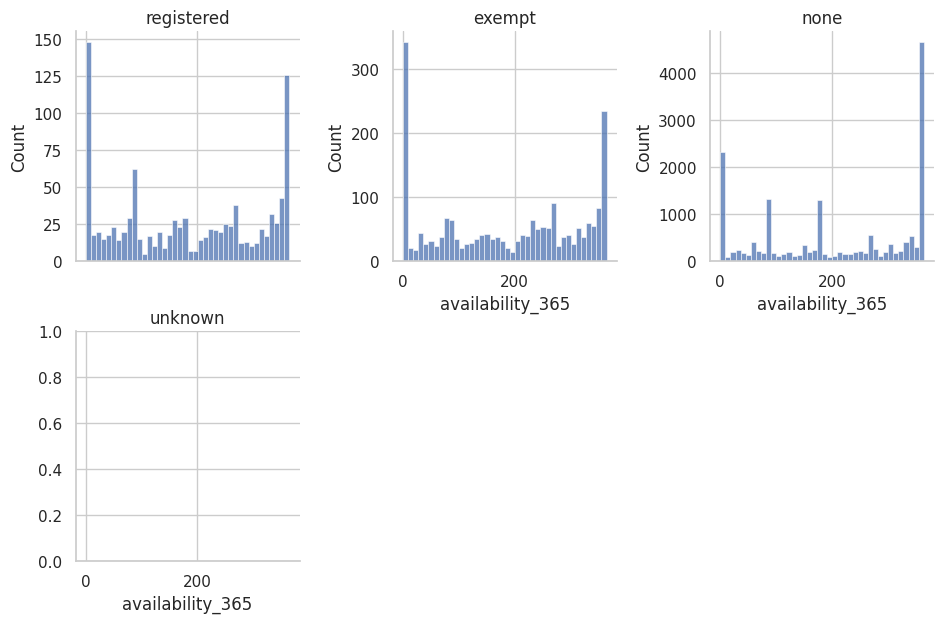

In [9]:
g = sns.FacetGrid(df, col="license_status", col_wrap=3, height=3.2, sharey=False)
g.map_dataframe(sns.histplot, x="availability_365", bins=40)
g.set_titles("{col_name}")

## 6. Geografia

Distancias con haversine, sin API de por medio.

Text(0, 0.5, 'latitude')

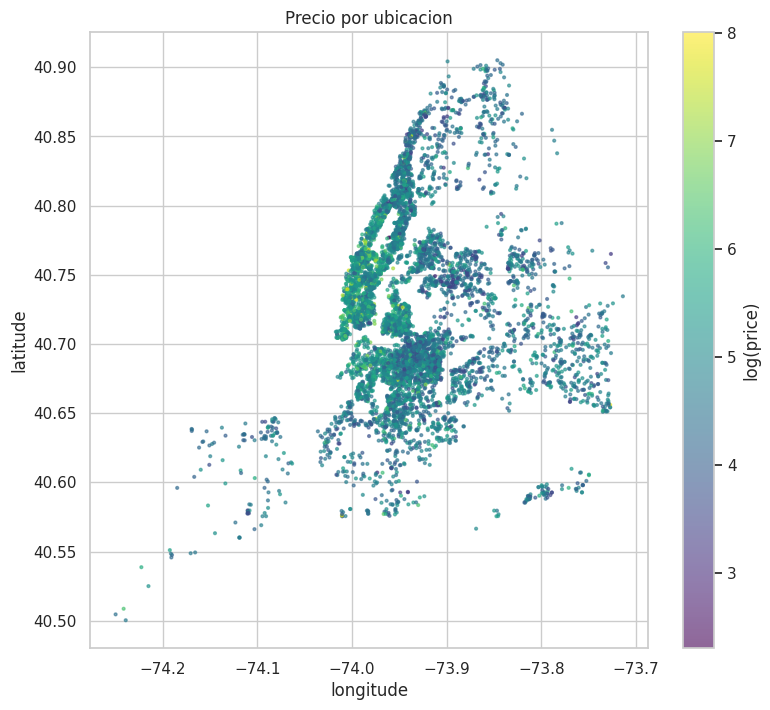

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))
sub = df.sample(min(8000, len(df)), random_state=42)
sc = ax.scatter(sub["longitude"], sub["latitude"], c=np.log(sub["price"]),
                s=4, cmap="viridis", alpha=0.6)
plt.colorbar(sc, label="log(price)")
ax.set_title("Precio por ubicacion")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")

In [11]:
dist_cols = [c for c in df.columns if c.startswith("dist_")]
df[dist_cols + ["price"]].corr()["price"].drop("price").sort_values()

dist_empire_state_km     -0.206253
dist_times_square_km     -0.201408
dist_wall_street_km      -0.191884
dist_central_park_s_km   -0.185094
dist_williamsburg_km     -0.126234
dist_jfk_airport_km       0.105458
Name: price, dtype: float64

## 7. Correlaciones

Ahora con las columnas que antes se perdian por ser texto.

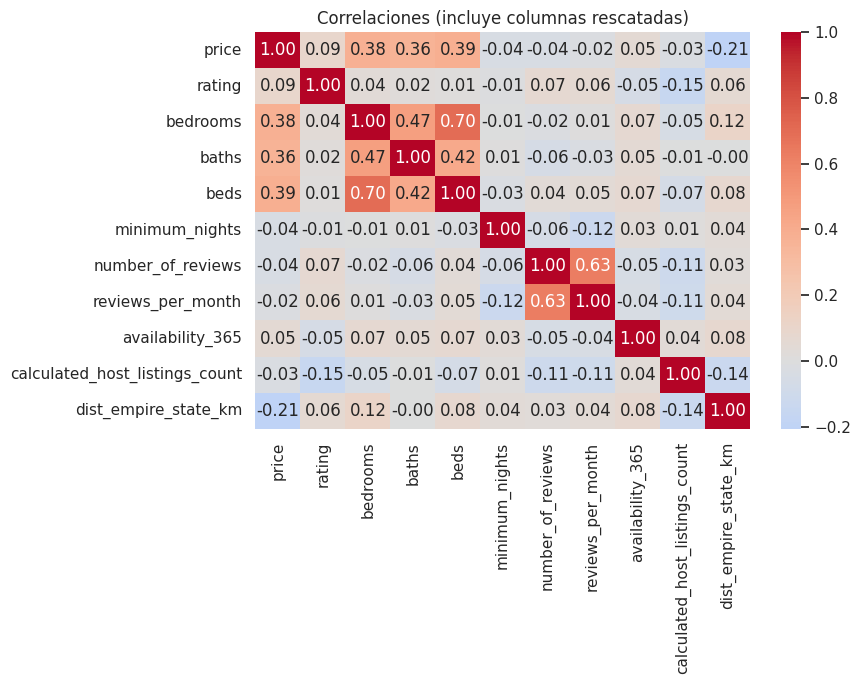

In [12]:
num = ["price", "rating", "bedrooms", "baths", "beds", "minimum_nights",
       "number_of_reviews", "reviews_per_month", "availability_365",
       "calculated_host_listings_count", "dist_empire_state_km"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlaciones (incluye columnas rescatadas)")
plt.tight_layout()

## Siguiente paso

El modelo no se entrena aqui a proposito: la validacion es por `GroupKFold`
sobre barrio y eso pide un script reproducible, no un kernel con estado.

```bash
python scripts/03_train.py
```
